In [95]:
import umap

import pandas as pd

from sklearn.manifold import TSNE


In [96]:
data = pd.read_csv("./data/DataModel.csv", sep=",")

In [97]:
data

,Year,Category,Region,Dist_EQ,PCT_CHARTER,PCT_NETWORK,PCT_REGIONAL,PCT_LCC
0,2002,NBI,AFRMY,1016.778341,0.059713,0.622493,0.267125,0.050669
1,2002,NBI,AMCS,1048.401762,0.000000,0.600042,0.377531,0.022427
2,2002,NBI,AMN,1409.858140,0.017363,0.590396,0.173806,0.218435
3,2002,NBI,ASIAUS,731.613261,0.000000,0.469682,0.466558,0.063759
4,2002,NBI,CEI,2021.616697,0.101249,0.335923,0.353537,0.209291
...,...,...,...,...,...,...,...,...
547,2024,NBS,ASIAUS,812.959679,0.005828,0.090262,0.756055,0.147855
548,2024,NBS,CEI,1639.145589,0.123707,0.000000,0.861040,0.015253
549,2024,NBS,CHN,1167.965411,0.000000,0.499884,0.446786,0.053330
550,2024,NBS,EUR,931.780060,0.033287,0.389731,0.127346,0.449636


In [98]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Prepare data - select all numerical features
numerical_features = [
    "Dist_EQ",
    "PCT_CHARTER",
    "PCT_NETWORK",
    "PCT_REGIONAL",
    "PCT_LCC",
    "Year",
]
X = data[numerical_features].to_numpy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode Category for shape
le_cat = LabelEncoder()
category_encoded = le_cat.fit_transform(data["Category"])

# Encode Region for coloring
le_reg = LabelEncoder()
region_encoded = le_reg.fit_transform(data["Region"])

Computing t-SNE...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 552 samples in 0.000s...
[t-SNE] Computed neighbors for 552 samples in 0.041s...
[t-SNE] Computed conditional probabilities for sample 552 / 552
[t-SNE] Mean sigma: 0.911585
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.317009
[t-SNE] KL divergence after 1500 iterations: 0.491543


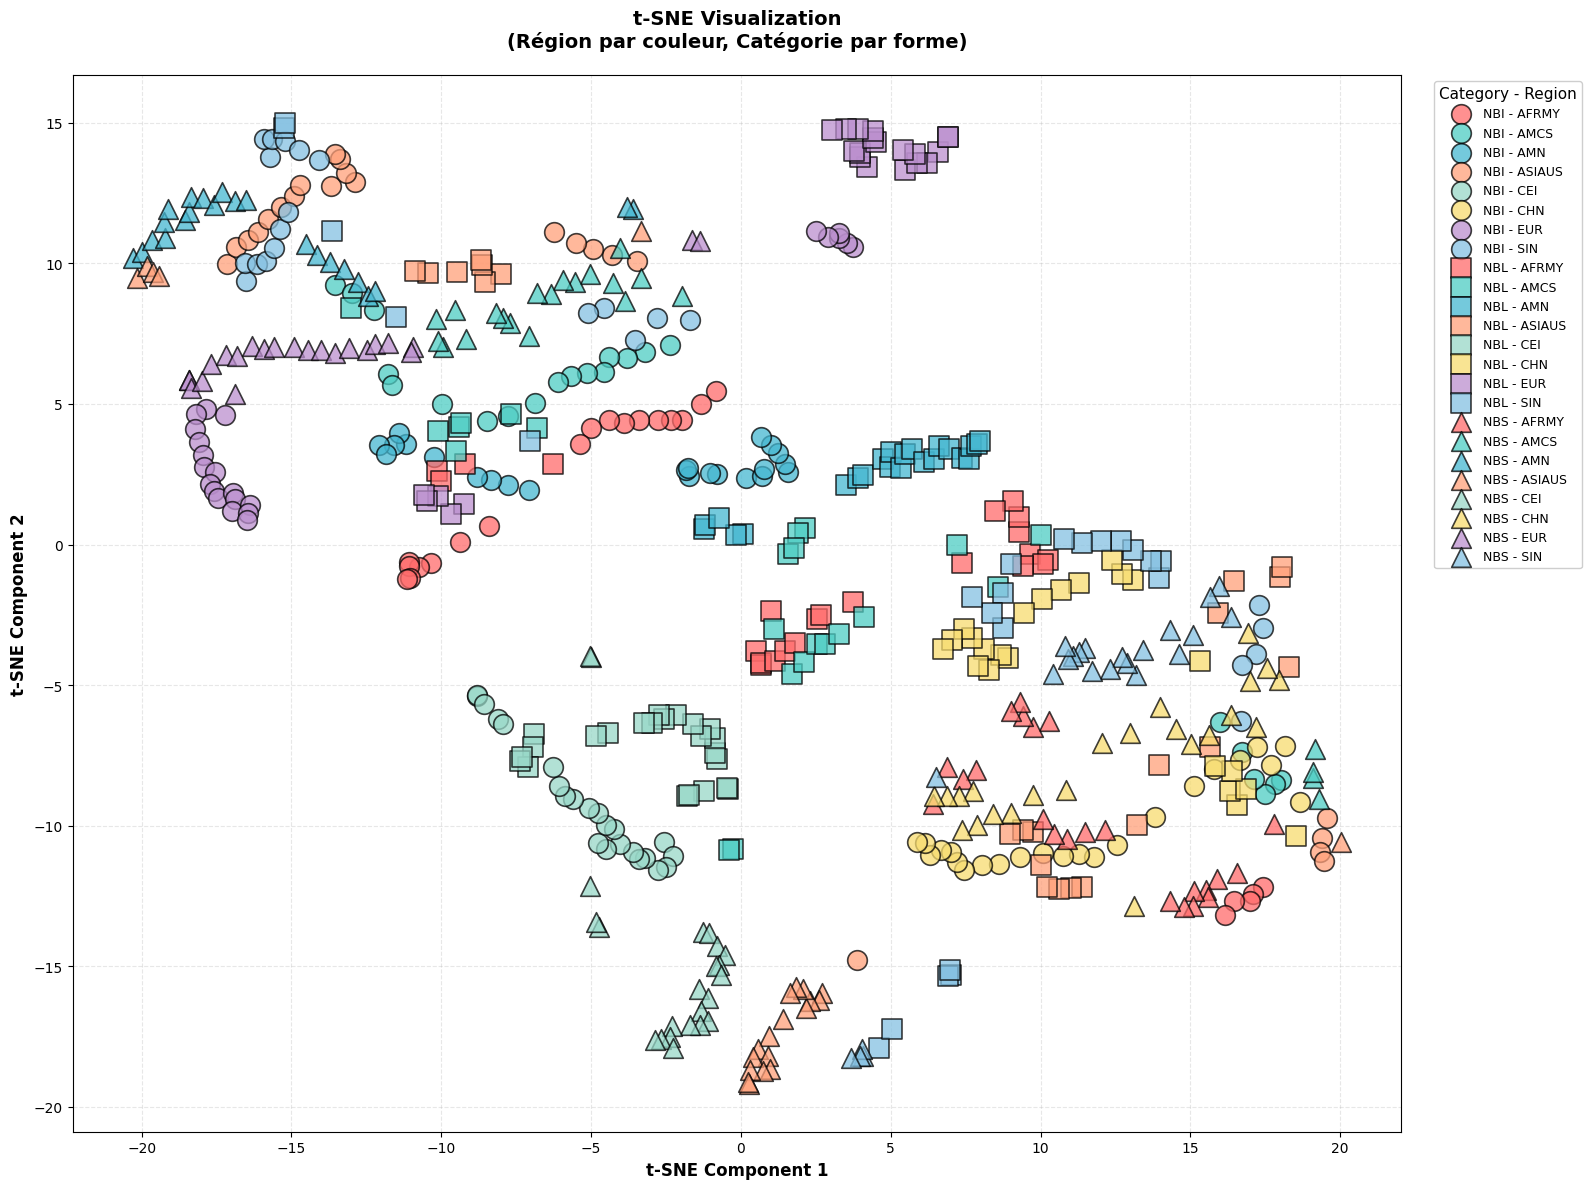


Categories: ['NBI' 'NBL' 'NBS']
Regions: ['AFRMY' 'AMCS' 'AMN' 'ASIAUS' 'CEI' 'CHN' 'EUR' 'SIN']
Markers: Circle=Circle (NBI), Square=Square (NBL), Triangle=Triangle (NBS)
Data points: 552


In [99]:
# t-SNE visualization with optimized parameters
print("Computing t-SNE...")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=50,
    max_iter=1500,
    learning_rate=200,
    verbose=1,
)
X_tsne = tsne.fit_transform(X_scaled)

# Create improved plot with better visuals
fig, ax = plt.subplots(figsize=(16, 12))

# Use a better color palette for regions
region_colors = {
    0: "#FF6B6B",  # AFRMY - red
    1: "#4ECDC4",  # AMCS - teal
    2: "#45B7D1",  # AMN - blue
    3: "#FFA07A",  # ASIAUS - light salmon
    4: "#98D8C8",  # CEI - mint
    5: "#F7DC6F",  # CHN - yellow
    6: "#BB8FCE",  # EUR - purple
    7: "#85C1E2",  # SIN - light blue
}

# Define larger, clearer markers for each category
markers = {0: "o", 1: "s", 2: "^"}
marker_names = {0: "Circle (NBI)", 1: "Square (NBL)", 2: "Triangle (NBS)"}

# Plot each combination of category and region with enhanced styling
handles = []
labels_legend = []

for cat in sorted(np.unique(category_encoded)):
    for reg in sorted(np.unique(region_encoded)):
        mask = (category_encoded == cat) & (region_encoded == reg)
        if np.any(mask):
            scatter = ax.scatter(
                X_tsne[mask, 0],
                X_tsne[mask, 1],
                c=region_colors[reg],
                marker=markers[cat],
                s=200,
                alpha=0.75,
                edgecolors="black",
                linewidth=1.2,
                label=f"{le_cat.classes_[cat]} - {le_reg.classes_[reg]}",
            )

# Create custom legend with two columns
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title="Category - Region",
    title_fontsize=11,
    ncol=1,
    framealpha=0.95,
)

ax.set_xlabel("t-SNE Component 1", fontsize=12, fontweight="bold")
ax.set_ylabel("t-SNE Component 2", fontsize=12, fontweight="bold")
ax.set_title(
    "t-SNE Visualization\n(Région par couleur, Catégorie par forme)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"\nCategories: {le_cat.classes_}")
print(f"Regions: {le_reg.classes_}")
print(
    f"Markers: Circle={marker_names[0]}, Square={marker_names[1]}, Triangle={marker_names[2]}",
)
print(f"Data points: {len(X_tsne)}")

Computing UMAP...


/Users/arthurdanjou/Workspace/studies/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


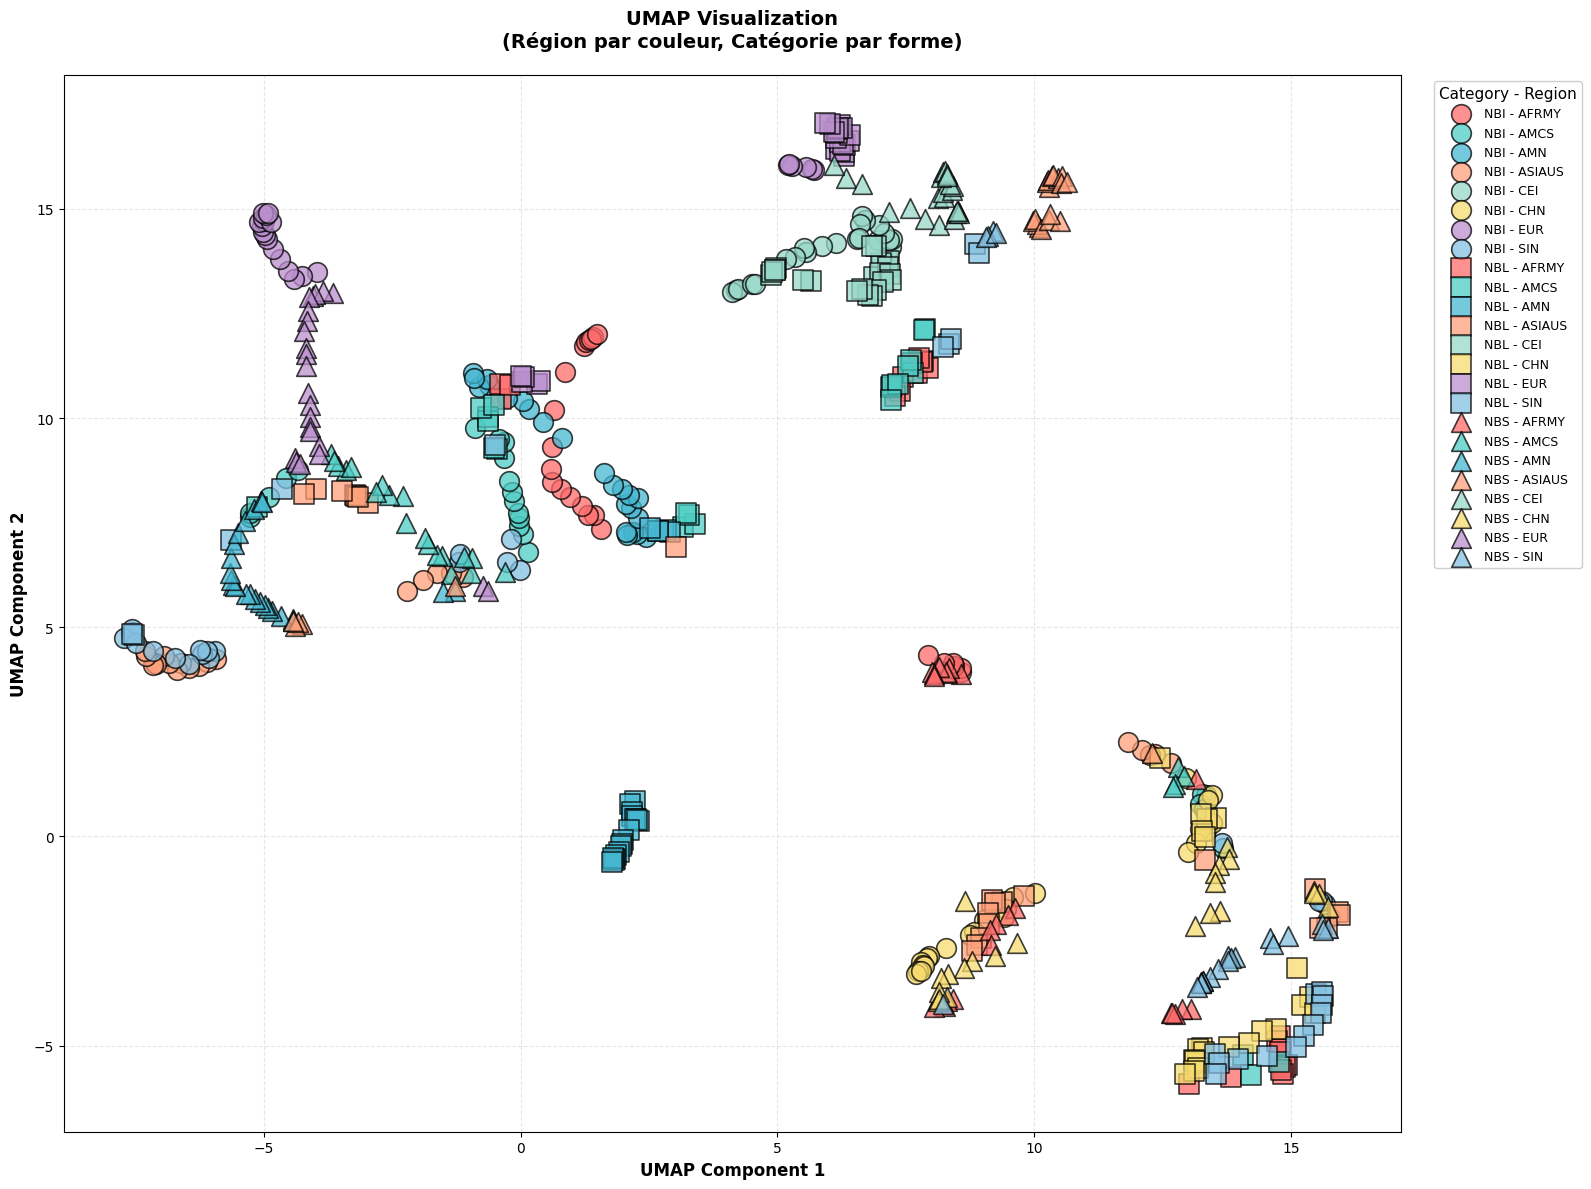


Categories: ['NBI' 'NBL' 'NBS']
Regions: ['AFRMY' 'AMCS' 'AMN' 'ASIAUS' 'CEI' 'CHN' 'EUR' 'SIN']
Markers: Circle=Circle (NBI), Square=Square (NBL), Triangle=Triangle (NBS)
Data points: 552


In [100]:
# UMAP visualization with optimized parameters
print("Computing UMAP...")
umap_reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=20,
    min_dist=0.05,
    metric="euclidean",
    spread=2.0,
)
X_umap = umap_reducer.fit_transform(X_scaled)

# Create improved plot with better visuals
fig, ax = plt.subplots(figsize=(16, 12))

# Use a better color palette for regions (same as t-SNE for consistency)
region_colors = {
    0: "#FF6B6B",  # AFRMY - red
    1: "#4ECDC4",  # AMCS - teal
    2: "#45B7D1",  # AMN - blue
    3: "#FFA07A",  # ASIAUS - light salmon
    4: "#98D8C8",  # CEI - mint
    5: "#F7DC6F",  # CHN - yellow
    6: "#BB8FCE",  # EUR - purple
    7: "#85C1E2",  # SIN - light blue
}

# Define larger, clearer markers for each category
markers = {0: "o", 1: "s", 2: "^"}
marker_names = {0: "Circle (NBI)", 1: "Square (NBL)", 2: "Triangle (NBS)"}

# Plot each combination of category and region with enhanced styling
for cat in sorted(np.unique(category_encoded)):
    for reg in sorted(np.unique(region_encoded)):
        mask = (category_encoded == cat) & (region_encoded == reg)
        if np.any(mask):
            ax.scatter(
                X_umap[mask, 0],
                X_umap[mask, 1],
                c=region_colors[reg],
                marker=markers[cat],
                s=200,
                alpha=0.75,
                edgecolors="black",
                linewidth=1.2,
                label=f"{le_cat.classes_[cat]} - {le_reg.classes_[reg]}",
            )

# Create custom legend
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title="Category - Region",
    title_fontsize=11,
    ncol=1,
    framealpha=0.95,
)

ax.set_xlabel("UMAP Component 1", fontsize=12, fontweight="bold")
ax.set_ylabel("UMAP Component 2", fontsize=12, fontweight="bold")
ax.set_title(
    "UMAP Visualization\n(Région par couleur, Catégorie par forme)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.grid(True, alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"\nCategories: {le_cat.classes_}")
print(f"Regions: {le_reg.classes_}")
print(
    f"Markers: Circle={marker_names[0]}, Square={marker_names[1]}, Triangle={marker_names[2]}",
)
print(f"Data points: {len(X_umap)}")